# Build Sol Dataset

## Install necessary libraries from python

In [ ]:
# import os

# src = "/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable"

# cnt = 0
# for file in os.listdir(src):
#     with open(src + "/" + file, "r") as f:
#         data = f.read()
#     if "block.timestamp" in data or "now" in data:
#         cnt =+ 1

# print(cnt)

In [12]:
%%capture
# Use Gpu
!pip install dgl==2.0.0 -f https://data.dgl.ai/wheels/cu121/repo.html
# Only use cpu
# !pip install dgl==1.1.2

In [13]:
%%capture
# !apt install libgraphviz-dev
# !pip install pygraphviz
!pip install networkx
!pip install slither-analyzer

## Import Python libraries

In [14]:
from concurrent.futures import ThreadPoolExecutor
from random import sample
import json
import multiprocessing
import traceback
import pandas as pd
import os
from pathlib import Path
import networkx as nx
# import pygraphviz as pgv
import matplotlib.pyplot as plt
import nltk
import dgl
import os
import shutil
import random
from slither.slither import Slither
from typing import Tuple, Optional, Dict
from copy import deepcopy
from pathlib import Path
import glob
from multiprocessing import Pool as ThreadPool
from functools import partial
import torch.nn as nn
import torch
from torch import Tensor
import torch.nn.functional as F
from dgl.nn import GraphConv, GATConv, TAGConv, SAGEConv, GINConv, SumPooling, AvgPooling, MaxPooling, SortPooling, GlobalAttentionPooling, WeightAndSum, Set2Set, SetTransformerEncoder, SetTransformerDecoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from dgl.nn.pytorch import Sequential
import pickle
import random
import numpy as np
from tqdm import tqdm

def seed_everything(seed: int):
    # Hàm đặt seed cố định cho tất cả các thư viện để kết quả có thể tái tạo lại được
    import random, os
    import numpy as np
    import torch
    
    random.seed(seed)  # Cố định seed cho thư viện random
    # os.environ['PYTHONHASHSEED'] = str(seed)  # Cố định hash seed của Python
    np.random.seed(seed)  # Cố định seed cho NumPy
    torch.manual_seed(seed)  # Cố định seed cho PyTorch CPU
    torch.cuda.manual_seed(seed)  # Cố định seed cho PyTorch GPU
    torch.backends.cudnn.deterministic = True  # Đảm bảo tính nhất quán của thuật toán cuDNN
    torch.backends.cudnn.benchmark = True  # Tối ưu hóa tốc độ tính toán

seed_everything(42)

# Functions

In [15]:
def plot(x: list, y: list):
  x = np.array(x)
  y = np.array(y)

  plt.plot(x, y)
  plt.title("Decrease of loss over epochs")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.show()

In [16]:
def readData(path: str, n_nscam: int, n_scam: int):
  dic = {
      "filename": [],
      "label": []
  }
  cnt0, cnt1 = 0, 0
  for label in ["NonVulnerable_Fcg", "Vulnerable_Fcg"]:
    for file in sorted(os.listdir(path + "/" + label)):
      if file.endswith(".fcg"):
        if label == "NonVulnerable_Fcg":
          if cnt0 <= n_nscam:
            dic['filename'].append("/".join([path, label, file]))
            dic['label'].append(0)
            cnt0 += 1
        else:
          if cnt1 <= n_scam:
            dic['filename'].append("/".join([path, label, file]))
            dic['label'].append(1)
            cnt1 += 1
  df = pd.DataFrame(dic)
  return df

In [34]:
def loadfeatureGraph_5(path):
    """
    path: path to fcg file
    
    return: dgl.DGLGraph with feature size of 5
    """
    g = dgl.load_graphs(path)[0][0]

# -------------------------------------------
    label = None
    if "NonVulnerable_Fcg" in path:
        label = 0
    else:
        label = 1        
    file_path_split = path.split("/")
    info_path = "/".join(file_path_split[:-1]) + "/" + file_path_split[-1].replace(".fcg", "_mapping.json")
    info_data = json.load(open(info_path, "r"))

    new_node_label = []
    for name, code in info_data['code'].items():
        if "Reentrancy" in info_path:
            if "call.value" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)
        else:
            if "block.timestamp" in code or "now" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)

    g.ndata['node_label'] = torch.tensor(new_node_label)
# -------------------------------------------
    
    return g, label

def loadfeatureGraph_100(path):
    """
    path: path to fcg file
    
    return: dgl.DGLGraph with feature size of 100
    """
    g = dgl.load_graphs(path)[0][0]

# -------------------------------------------
    label = None
    if "NonVulnerable_Fcg" in path:
        label = 0
    else:
        label = 1        
    file_path_split = path.split("/")
    info_path = "/".join(file_path_split[:-1]) + "/" + file_path_split[-1].replace(".fcg", "_mapping.json")
    info_data = json.load(open(info_path, "r"))

    new_node_label = []
    for name, code in info_data['code'].items():
        if "Reentrancy" in info_path:
            if "call.value" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)
        else:
            if "block.timestamp" in code or "now" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)

    g.ndata['node_label'] = torch.tensor(new_node_label)
# -------------------------------------------
    
    g.ndata["features"] = g.ndata["featuresH"]
    return g, label

def loadfeatureGraph_105(path):
    """
    path: path to fcg file
    
    return: dgl.DGLGraph with feature size of 105
    """
    g = dgl.load_graphs(path)[0][0]
    template = g.ndata["features"]
    

# -------------------------------------------
    label = None
    if "NonVulnerable_Fcg" in path:
        label = 0
    else:
        label = 1        
    file_path_split = path.split("/")
    info_path = "/".join(file_path_split[:-1]) + "/" + file_path_split[-1].replace(".fcg", "_mapping.json")
    info_data = json.load(open(info_path, "r"))

    new_node_label = []
    for name, code in info_data['code'].items():
        if "Reentrancy" in info_path:
            if "call.value" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)
        else:
            if "block.timestamp" in code or "now" in code:
                new_node_label.append(1)
            else:
                new_node_label.append(0)

    g.ndata['node_label'] = torch.tensor(new_node_label)
# -------------------------------------------
    
    g.ndata["features"] = torch.cat([g.ndata["featuresH"], template], dim=1)
    return g, label

def createBatchMulThread_MultiOp(data, max_works, nfeatures):
    """
    data: Graph paths,
    nfeatures: Size of node feature
    max_works: number of thread use
    
    return list[DGLGraph]
    """
    pathfiles = data
    if nfeatures == 5:
        with ThreadPoolExecutor(max_works) as executor:
            graph_n_label = list(executor.map(loadfeatureGraph_5, pathfiles))
    elif nfeatures == 768:
        with ThreadPoolExecutor(max_works) as executor:
            graph_n_label = list(executor.map(loadfeatureGraph_100, pathfiles))
    elif nfeatures == 773:
        with ThreadPoolExecutor(max_works) as executor:
            graph_n_label = list(executor.map(loadfeatureGraph_105, pathfiles))

    graphs, labels = [], []
    for g, label in graph_n_label:
        cnt = 0
        for nlabel in g.ndata['node_label'].tolist():
            if nlabel == 1:
                cnt += 1
        num_classes = len(torch.unique(g.ndata['node_label']))
        if cnt == 1:
            graphs.append(g)
            labels.append(label)
    # graphs, labels = [], []
    # for graph, label in graph_n_label:
    #     graphs.append(graph)
    #     labels.append(label)
            
    return graphs, labels

In [ ]:
# /kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/NonVulnerable_Fcg/0x073c4ea5a89d0e5aa0408a1b6dd8bbfcdba985c0.fcg

# Model GNNs

In [29]:
import dgl.nn.pytorch as dglnn
import torch.nn as nn
from copy import deepcopy as dc

#---------------------------------------------------------------------------------------------------------------------
class MultiHeadCrossAttentionPooling(nn.Module):
    def __init__(self, hidden_dim, num_query_vectors=1, num_heads=4):
        super(MultiHeadCrossAttentionPooling, self).__init__()
        self.num_query_vectors = num_query_vectors
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        
        # Single set of query vectors, will be reshaped for multi-head
        self.query = nn.Parameter(torch.randn(num_query_vectors, hidden_dim))
        
        # Single transformations that will be reshaped for multi-head attention
        self.key_transform = nn.Linear(hidden_dim, hidden_dim)
        self.value_transform = nn.Linear(hidden_dim, hidden_dim)
        
        # Output projection
        self.output_projection = nn.Linear(hidden_dim, hidden_dim)
        
        # Final output dimension
        self.output_dim = hidden_dim * num_query_vectors
        
    def forward(self, g, h):
        graph_splits = g.batch_num_nodes()
        batch_size = len(graph_splits)
        device = h.device
        output = torch.zeros(batch_size, self.output_dim, device=device)
        
        # Transform once for all heads
        keys = self.key_transform(h)      # (total_nodes x hidden_dim)
        values = self.value_transform(h)   # (total_nodes x hidden_dim)
        
        # Reshape for multi-head attention
        # Reshape to: [num_nodes, num_heads, hidden_dim/num_heads]
        keys = keys.view(-1, self.num_heads, self.hidden_dim // self.num_heads)
        values = values.view(-1, self.num_heads, self.hidden_dim // self.num_heads)
        query = self.query.view(self.num_query_vectors, self.num_heads, -1)
        
        start_idx = 0
        for i, num_nodes in enumerate(graph_splits):
            end_idx = start_idx + num_nodes
            
            # Get current graph's nodes
            graph_keys = keys[start_idx:end_idx]    # (num_nodes x num_heads x head_dim)
            graph_values = values[start_idx:end_idx] # (num_nodes x num_heads x head_dim)
            
            # Calculate attention scores (for all heads simultaneously)
            scores = torch.matmul(query.permute(1, 0, 2), graph_keys.permute(1, 2, 0))
            # scores shape: [num_heads, num_queries, num_nodes]
            
            attention_weights = F.softmax(scores / (self.hidden_dim // self.num_heads) ** 0.5, dim=-1)
            
            # Apply attention
            head_outputs = torch.matmul(attention_weights, graph_values.permute(1, 0, 2))
            # head_outputs shape: [num_heads, num_queries, head_dim]
            
            # Concatenate heads and reshape
            multi_head_output = head_outputs.permute(1, 0, 2).reshape(self.num_query_vectors, -1)
            
            # Project output
            projected_output = self.output_projection(multi_head_output)
            
            # Store result
            output[i] = projected_output.reshape(-1)
            
            start_idx = end_idx
        
        return output
#---------------------------------------------------------------------------------------------------------------------

def get_convolution_layer(
            input_dimension: int,
            output_dimension: int,
            name: list,
            agg_hidden_dimension: int = 1024, # Only use for GINConv
            heads: int = 0 # Only use for GATConv
    ) -> Optional[nn.Module]:
        mlp, gin_agg, sage_agg = None, 'sum', 'mean'
        if name[0] == "GIN":
          mlp = nn.Sequential()
          mlp.append(nn.Linear(input_dimension, agg_hidden_dimension))
          mlp.append(nn.ReLU())
          mlp.append(nn.Linear(agg_hidden_dimension, output_dimension))
          gin_agg = name[1]

        if name[0] == "SAGE":
          sage_agg = name[1]

        return {"GCN": GraphConv(input_dimension, output_dimension, activation=F.relu),
                "SAGE": SAGEConv(input_dimension, output_dimension, activation=F.relu, norm=F.normalize, aggregator_type=sage_agg),
                "GAT": GATConv(input_dimension, output_dimension, num_heads=heads, activation=F.relu, feat_drop=0.0, attn_drop=0.0),
                "TAG": TAGConv(input_dimension, output_dimension, k=4, activation=F.relu),
                "GIN": GINConv(apply_func=mlp, activation=F.relu, aggregator_type=gin_agg)
                }.get(name[0], None)

def get_pooling_method(
            method_name: str,
            hidden_dim: int = None  # Add hidden_dim parameter
    ):
        return {"max": MaxPooling(),
                "mean": AvgPooling(),
                "sum": SumPooling(),
                "sort": SortPooling(k=3),
                "transformer": (SetTransformerEncoder(5, 4, 4, 20), SetTransformerDecoder(5, 4, 4, 20, 1, 3)),
                "global_attention": GlobalAttentionPooling(gate_nn=nn.Linear(hidden_dim, 1),
                                                         feat_nn=nn.Linear(hidden_dim, hidden_dim))
                }.get(method_name, None)

class GraphNN(nn.Module):
    def __init__(self, mtype, infeats, hfeats: list, fc1_layer, fc2_layer, n_gph, outclass, gptype='max', ginfeat=None, num_query_vectors=1):
        super(GraphNN, self).__init__()
        self.mtype = mtype
        self.gptype = gptype
        self.hfeats = hfeats
        self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

        if mtype[0] == "GIN":          
          self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0],
                                             name=mtype, agg_hidden_dimension=ginfeat)
          
          if len(hfeats) >= 2:
            self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1],
                                               name=mtype, agg_hidden_dimension=ginfeat)
          if len(hfeats) >= 3:
            self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2],
                                               name=mtype, agg_hidden_dimension=ginfeat)
        else:          
          if mtype != ["GAT"]:
            self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype)
            if len(hfeats) >= 2:
                self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1], name=mtype)
            if len(hfeats) >= 3:
                self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2], name=mtype)
          else:
            if len(hfeats) > 1:
              self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype, heads=8)
            elif len(hfeats) == 1:
              self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype, heads=1)
              # self.GPH_1 = get_convolution_layer(input_dimension=hfeats[-1], output_dimension=hfeats[-1], name=mtype, heads=1)
            if len(hfeats) > 2:
              self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=hfeats[1], name=mtype, heads=8)
            elif len(hfeats) == 2:
              self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=hfeats[1], name=mtype, heads=1)
              # self.GPH_2 = get_convolution_layer(input_dimension=hfeats[-1], output_dimension=hfeats[-1], name=mtype, heads=1)
            if len(hfeats) == 3:
              self.conv3 = get_convolution_layer(input_dimension=(hfeats[1] * 8), output_dimension=hfeats[2], name=mtype, heads=1)
              # self.GPH_3 = get_convolution_layer(input_dimension=hfeats[-1], output_dimension=hfeats[-1], name=mtype, heads=1)

        if mtype == ["GIN"]:
            self.GPH = Sequential(*[get_convolution_layer(input_dimension=hfeats[-1], output_dimension=hfeats[-1],
                                                            name=mtype, agg_hidden_dimension=ginfeat) for i in range(n_gph)])
        else:
            if mtype != ["GAT"]:
                self.GPH = Sequential(*[get_convolution_layer(input_dimension=hfeats[-1], 
                                                                output_dimension=hfeats[-1], name=mtype) for i in range(n_gph)])
            else:
                self.GPH = Sequential(*[get_convolution_layer(input_dimension=hfeats[-1], 
                                                                output_dimension=hfeats[-1], name=mtype, heads=1) for i in range(n_gph)])
        
        # In GraphNN's __init__
        if gptype == 'cross_attention':
            self.pooling = MultiHeadCrossAttentionPooling(hidden_dim=hfeats[-1], num_query_vectors=num_query_vectors)
            fc1_input_dim = hfeats[-1] * num_query_vectors
        else:
            self.pooling = get_pooling_method(gptype, hidden_dim=hfeats[-1])  # Pass the hidden dimension
            fc1_input_dim = hfeats[-1]

        # Adjust FC layers for concatenated output
        self.fc1 = nn.Linear(fc1_input_dim, fc1_layer)
        self.fc2 = nn.Linear(fc1_layer, fc2_layer)
        self.fc3 = nn.Linear(fc2_layer, outclass)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)
    
    def create_graph_adjacency(self, num_nodes):
        src = []
        dest = []
        for i in range(num_nodes):
            for j in range(num_nodes):
                if i != j:
                    src.append(i)
                    dest.append(j)
        src = torch.tensor(src)
        dest = torch.tensor(dest)
        return dgl.graph((src, dest), num_nodes=num_nodes)

    def create_graph(self, features):
        g = self.create_graph_adjacency(features.shape[0])
        g = g.add_self_loop().to(self.device)
        g.ndata["features"] = features
        return g.add_self_loop().to(self.device)
        
    def forward(self, g, infeats):
        # Apply graph convolution and activation.
        h = self.conv1(g, infeats)
        if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        if len(self.hfeats) >= 2:
          h = self.conv2(g, h)
          if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        if len(self.hfeats) >= 3:
          h = self.conv3(g, h)
          if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        # with g.local_scope():

        g.ndata['features'] = h
        if self.gptype == "cross_attention":
            h = self.pooling(g, g.ndata['features'])
        elif self.gptype == "transformer":
            enc_nodes, dec_nodes = get_pooling_method(self.gptype)
            h = enc_nodes(g, g.ndata['features'])
            h = dec_nodes(g, g.ndata['features'])
        else:
            h = self.pooling(g, g.ndata['features'])

        if len(self.GPH) != 0:
            g = self.create_graph(h.clone())
            h_gph = self.GPH(g, g.ndata['features'])
            h += h_gph.squeeze()
        ans = self.fc1(h)
        ans = F.relu(ans)
        ans = self.fc2(ans)
        ans = F.relu(ans)
        return self.fc3(ans)

    def save(self, path):
      torch.save(self.state_dict(), path)

    def load(self, path):
      self.load_state_dict(torch.load(path))

# Training

In [30]:
from dgl.data import DGLDataset
from dgl.dataloading import GraphDataLoader

class GraphDataset(DGLDataset):
    def __init__(self, graphs, labels):
        super().__init__(name='graph_dataset')
        self.graphs = graphs
        self.labels = labels
    def process(self):
        # Here, you could preprocess the data if needed.
        pass

    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]

    def __len__(self):
        return len(self.graphs)

In [31]:
def seed_everything(seed: int):
    # Hàm đặt seed cố định cho tất cả các thư viện để kết quả có thể tái tạo lại được
    import random, os
    import numpy as np
    import torch
    
    random.seed(seed)  # Cố định seed cho thư viện random
    # os.environ['PYTHONHASHSEED'] = str(seed)  # Cố định hash seed của Python
    np.random.seed(seed)  # Cố định seed cho NumPy
    torch.manual_seed(seed)  # Cố định seed cho PyTorch CPU
    torch.cuda.manual_seed(seed)  # Cố định seed cho PyTorch GPU
    torch.backends.cudnn.deterministic = True  # Đảm bảo tính nhất quán của thuật toán cuDNN
    torch.backends.cudnn.benchmark = True  # Tối ưu hóa tốc độ tính toán
    
def train_and_eval(dataloader, tdataloader, mtype, s_epoch, e_epoch, n_workers, n_feats, hfeats, n_gph, gptype, ginfeat, num_query_vectors):
    seed_everything(42)
    model = GraphNN(mtype=mtype, infeats=n_feats, hfeats=hfeats, fc1_layer=256, fc2_layer=64, n_gph=n_gph, outclass=2, gptype=gptype, ginfeat=ginfeat)
    model.to(model.device)
    print(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = torch.nn.CrossEntropyLoss()

    result = {
        "data": os.path.basename(data_path),
        "loss":[],
        "val_acc": [],
        "val_f1": [],
        "epoch": []
    }

    for epoch in (range(s_epoch, e_epoch)):
        bloss, bpred, blabel = [], [], []
        for batched_graph, label_batch in dataloader:
            batched_graph, label_batch = batched_graph.to(model.device), label_batch.to(model.device)
            feats = batched_graph.ndata['features']
            model.train()
            pred_batch = model(batched_graph, feats)
            loss = criterion(pred_batch, label_batch)
            out_batch = pred_batch.argmax(dim=1).long()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            bloss.append(loss.item())
            bpred.extend(out_batch.tolist())
            blabel.extend(label_batch.tolist())


        result['loss'].append(sum(bloss)/len(bloss))
        result['epoch'].append(epoch)
        print("Epoch:", epoch, "   Loss:", sum(bloss)/len(bloss),f"   Accuracy: {(accuracy_score(bpred, blabel)* 100):.4f}%")
        # if os.path.exists(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}") == False:
        #     os.mkdir(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}")
        # model.save(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}/model_{os.path.basename(data_path)}_{str(epoch).zfill(2)}.pt")
        model.eval()
        with torch.no_grad():
            tpred, tlabel = [], []
            for tbatched_graph, tlabels in (tdataloader):
                tbatched_graph, tlabels = tbatched_graph.to(model.device), tlabels.to(model.device)
                tfeats = tbatched_graph.ndata['features']
                out = model(tbatched_graph, tfeats)
                preds = out.argmax(dim=1).long()
                tpred.extend(preds.tolist())
                tlabel.extend(tlabels.tolist())

            print(f'Val Accuracy: {(accuracy_score(tlabel, tpred) * 100):.2f}%')
            print(f'Val F1 Score: {(f1_score(np.array(tlabel), np.array(tpred)) * 100):.2f}%')
            print(f'Val Precision: {(precision_score(tlabel, tpred) * 100):.2f}%')
            print(f'Val Recall: {(recall_score(tlabel, tpred) * 100):.2f}%')
            result['val_acc'].append(accuracy_score(tlabel, tpred))
            result['val_f1'].append(f1_score(np.array(tlabel), np.array(tpred)))

    print("loss")
    plot(result["epoch"], result["loss"])
    print("val_acc")
    plot(result["epoch"], result["val_acc"])
    print("val_f1")
    plot(result["epoch"], result["val_f1"])
    return result

In [35]:
import random

data_path = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset"

train_df = readData(f"{data_path}/Train", 2047, 2047)
train_df = train_df.sample(frac=1).reset_index(drop=True)

test_df = readData(f"{data_path}/Test", 2047, 2047)
test_df = test_df.sample(frac=1).reset_index(drop=True)

display(train_df.head())
display(test_df.head())

X_train, y_train = train_df.drop(['label'], axis=1), train_df['label']
X_test, y_test = test_df.drop(['label'], axis=1), test_df['label']
# X_train, X_test, y_train, y_test = train_test_split(df.drop(['label'], axis=1), df['label'], test_size=0.2, random_state=42)

graphs, y_train  = createBatchMulThread_MultiOp(X_train['filename'].tolist(), 16, 768)
print(f"Train Dataset size: {len(graphs)} files")
graphs = [dgl.add_self_loop(g) for g in graphs]
dataset = GraphDataset(graphs, Tensor(list(y_train)).long())
dataloader = GraphDataLoader(
    dataset,
    batch_size=128,
    drop_last=False,
    shuffle=True)

tgraphs, y_test = createBatchMulThread_MultiOp(X_test['filename'].tolist(), 16, 768)
print(f"Test Dataset size: {len(tgraphs)} files")
tgraphs = [dgl.add_self_loop(g) for g in tgraphs]
tdataset = GraphDataset(tgraphs, Tensor(list(y_test)).long())
tdataloader = GraphDataLoader(
    tdataset,
    batch_size=512,
    drop_last=False,
    shuffle=True)

,filename,label
0,/kaggle/input/sol2graphconverter/SmartContract...,0
1,/kaggle/input/sol2graphconverter/SmartContract...,1
2,/kaggle/input/sol2graphconverter/SmartContract...,0
3,/kaggle/input/sol2graphconverter/SmartContract...,1
4,/kaggle/input/sol2graphconverter/SmartContract...,1


,filename,label
0,/kaggle/input/sol2graphconverter/SmartContract...,0
1,/kaggle/input/sol2graphconverter/SmartContract...,0
2,/kaggle/input/sol2graphconverter/SmartContract...,1
3,/kaggle/input/sol2graphconverter/SmartContract...,0
4,/kaggle/input/sol2graphconverter/SmartContract...,0


Train Dataset size: 300 files
Test Dataset size: 65 files


In [ ]:
# print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/NonVulnerable")))
# print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/Vulnerable")))

In [ ]:
# print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Train/NonVulnerable")))
# print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Train/Vulnerable")))

# Run training

/usr/local/lib/python3.10/dist-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


GraphNN(
  (conv1): GraphConv(in=768, out=2048, normalization=both, activation=<function relu at 0x784b826a7010>)
  (conv2): GraphConv(in=2048, out=2048, normalization=both, activation=<function relu at 0x784b826a7010>)
  (GPH): Sequential(
    (0): GraphConv(in=2048, out=2048, normalization=both, activation=<function relu at 0x784b826a7010>)
  )
  (pooling): MaxPooling()
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)
Epoch: 0    Loss: 2.3916105329990387    Accuracy: 52.6667%
Val Accuracy: 73.85%
Val F1 Score: 84.96%
Val Precision: 73.85%
Val Recall: 100.00%
Epoch: 1    Loss: 1.1201659639676411    Accuracy: 66.0000%
Val Accuracy: 26.15%
Val F1 Score: 0.00%


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Val Precision: 0.00%
Val Recall: 0.00%
Epoch: 2    Loss: 0.8295713663101196    Accuracy: 54.0000%
Val Accuracy: 73.85%
Val F1 Score: 84.96%
Val Precision: 73.85%
Val Recall: 100.00%
Epoch: 3    Loss: 0.7248760064442953    Accuracy: 62.6667%
Val Accuracy: 41.54%
Val F1 Score: 40.62%
Val Precision: 81.25%
Val Recall: 27.08%
Epoch: 4    Loss: 0.6199359695116679    Accuracy: 59.0000%
Val Accuracy: 73.85%
Val F1 Score: 84.96%
Val Precision: 73.85%
Val Recall: 100.00%
Epoch: 5    Loss: 0.6608069141705831    Accuracy: 68.6667%
Val Accuracy: 73.85%
Val F1 Score: 84.96%
Val Precision: 73.85%
Val Recall: 100.00%
Epoch: 6    Loss: 0.6410106420516968    Accuracy: 69.0000%
Val Accuracy: 73.85%
Val F1 Score: 84.96%
Val Precision: 73.85%
Val Recall: 100.00%
Epoch: 7    Loss: 0.6306480765342712    Accuracy: 69.0000%
Val Accuracy: 73.85%
Val F1 Score: 84.96%
Val Precision: 73.85%
Val Recall: 100.00%
Epoch: 8    Loss: 0.6150210698445638    Accuracy: 68.6667%
Val Accuracy: 73.85%
Val F1 Score: 84.96%
Val

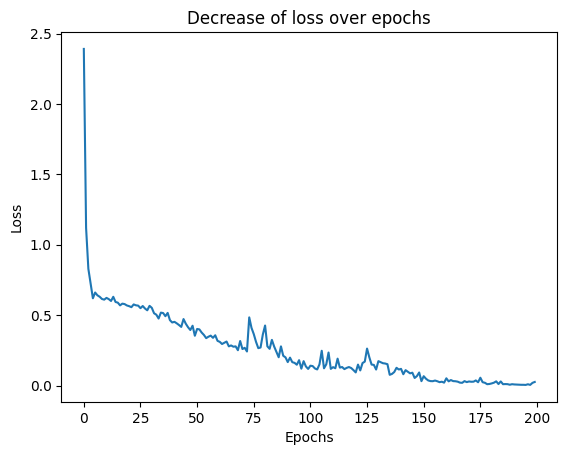

val_acc


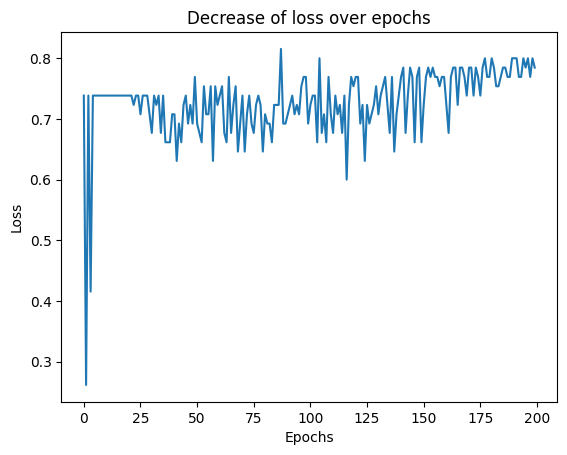

val_f1


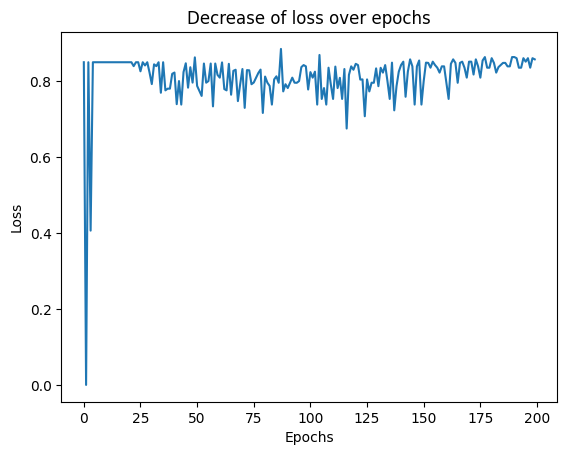

In [39]:
# GCN, SAGE, GAT, TAG, GIN
# layer 1, 2, 3
# 128
# 256, 128
# 256, 256, 128

n_feats = 768
n_batch=128

# result_dict = {}
# for mtype in [['GAT'], ['SAGE', 'pool'], ['SAGE', 'mean'], ['SAGE', 'lstm'], ['GCN'], ['TAG'], ['GIN', 'max'], ['GIN', 'sum'], ['GIN', 'mean']]:
#     for hfeats in [[128], [256, 128], [256, 256, 128]]:
#         for gptype in ['cross_attention']: # 'sum', 'mean', 'max', 
#             for n_gph in range(0, 4):
#                 try:
#                     print(mtype, hfeats, gptype, n_gph)
#                     tmp = train_and_eval(dataloader=dataloader, tdataloader=tdataloader, mtype=mtype,
#                                                 s_epoch=0, e_epoch=200, n_workers=64, n_gph=n_gph, n_feats=n_feats,
#                                                 hfeats=hfeats, gptype=gptype, ginfeat=1024, num_query_vectors=2)
#                     res = [(i, j) for i, j in zip(tmp['val_f1'], tmp['val_acc'])]
#                     print(max(res))
#                     result_dict[f"{mtype}_{hfeats}_{gptype}_{n_gph}"] = tmp
#                 except: 
#                     pass

result = train_and_eval(dataloader=dataloader, tdataloader=tdataloader, mtype=['GCN'],
                                        s_epoch=0, e_epoch=200, n_workers=64, n_gph=1, n_feats=n_feats,
                                        hfeats=[2048, 2048], gptype='max', ginfeat=1024, num_query_vectors=2)

In [40]:
res = [(i, j) for i, j in zip(result['val_f1'], result['val_acc'])]
print(max(res))

(0.8846153846153847, 0.8153846153846154)


In [ ]:
# (0.8955223880597014, 0.8882978723404256)

In [ ]:
import json
def write_json(data, file):
    with open(file, "w") as f:
        json.dump(data, f, indent=4)
write_json(result_dict, '/kaggle/working/result_cross_attention.json')

In [ ]:
import json
def read_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    return data
def get_max(result):
    f1, acc = max([(i, j) for i, j in zip(result['val_f1'], result['val_acc'])])
    return f1, acc
mtype = []
ls_f1 = []
ls_acc = []
for name, values in result_dict.items():
    f1, acc = get_max(values)
    # print(values.keys())
    mtype.append(name) 
    ls_f1.append(f1) 
    ls_acc.append(acc) 
    # break
import pandas as pd
data = pd.DataFrame({
    "mtype": mtype,
    "f1": ls_f1,
    "acc": ls_acc
})    
data.to_excel("/kaggle/working/result_cross_attention.xlsx")

In [ ]:
# import json

# line_list = [EFcgDataset]
# name_list = ['EFcgDataset']

# for i in range(len(line_list)):
#   with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/plots/{name_list[i]}_{mtype}_{len(hfeats)}.json", "w") as outfile:
#       json.dump(line_list[i], outfile)

In [ ]:
# # importing package
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.interpolate import make_interp_spline

# def ploting(line_list, name_list, line_type):
#   epoches = range(350)
#   plt.figure(figsize=(10, 10))
#   for i in range(len(line_list)):
#     # plot lines
#     X_Y_Spline = make_interp_spline(epoches, line_list[i][line_type])
#     X_ = np.linspace(min(epoches), max(epoches), 50000)
#     Y_ = X_Y_Spline(X_)

#     plt.plot(X_, Y_, label = name_list[i])
#   plt.legend()
#   plt.show()

# ploting([EFcgDataset], ['EFcgDataset - GAT - 2'], 'val_f1')

In [ ]:
# # (0.852112676056338, 0.8775510204081632)
# res = [(i, j) for i, j in zip(EFcgDataset['val_f1'], EFcgDataset['val_acc'])]

# print(max(res))

# Checking

In [ ]:
# !mkdir  /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam
# !mkdir  /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam

In [ ]:
# # !zip -r /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam/EFcgDataset_NonScam.zip /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/NonScam
# !zip -r /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam/EFcgDataset_Scam.zip /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam

In [ ]:
# import os
# import json
# # quangnguyen11037 benign (1 - 13)
# # quangnguyen2910 benign (14 - 25)
# # quangnm711 malware (full)

# dictionary = {
#   "title": f"Sol_Dataset_EFcg_NonScam",
#   "id": f"quangnguyen11037/sol-dataset-efcg-nonscam",
#   "licenses": [
#     {
#       "name": "CC0-1.0"
#     }
#   ]
# }

# # Serializing json
# json_object = json.dumps(dictionary, indent=2)

# # Writing to sample.json
# with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam/dataset-metadata.json", "w") as outfile:
#     outfile.write(json_object)

# dictionary = {
#   "title": f"Sol_Dataset_EFcg_Scam",
#   "id": f"quangnguyen11037/sol-dataset-efcg-scam",
#   "licenses": [
#     {
#       "name": "CC0-1.0"
#     }
#   ]
# }

# # Serializing json
# json_object = json.dumps(dictionary, indent=2)

# # Writing to sample.json
# with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam/dataset-metadata.json", "w") as outfile:
#     outfile.write(json_object)

In [ ]:
# os.environ['KAGGLE_CONFIG_DIR'] = "/content/quangnguyen11037"

In [ ]:
# !chmod 600 /content/quangnguyen11037/kaggle.json

In [ ]:
# !kaggle datasets create -p /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam --dir-mode skip --public
# !kaggle datasets create -p /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam --dir-mode skip --public